## Implementing Linear Regression from Scratch

In the first section of the notebook, I will learn and implement linear regression model from scratch just using basic Python and leverage vectorization libraries such as numpy.

In [38]:
import math
import numpy as np
import pandas as pd
import pickle
import plotly.express as px
import matplotlib.pyplot as plt

### Loading the data and analysis

In [39]:
train_data = pd.read_csv('./data/train.csv')
test_data = pd.read_csv('./data/test.csv')

In [40]:
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

In [41]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       699 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 16.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       300 non-null    int64  
 1   y       300 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.8 KB


### Plotting the data

In [42]:
px.scatter(x = train_data['x'], y = train_data['y'], template = 'seaborn')

C:\Users\mosbi\AppData\Local\Temp\ipykernel_24620\3308871478.py:1: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



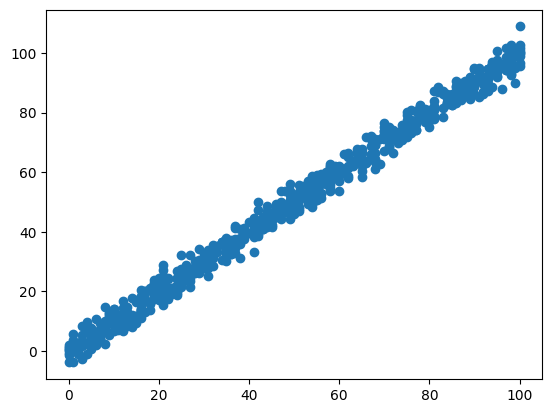

In [43]:
scatter_plt = plt.scatter(train_data['x'], train_data['y'], cmap= "seaborn")

### Data Preprocessing

In [44]:
X_train = train_data['x'].values
Y_train = train_data['y'].values

X_test = train_data['x'].values
Y_test = test_data['y'].values

In [53]:
print(f"X_train's shape is {X_train.shape}")
print(f"X_test's shape is {X_test.shape}")
print(f"Y_train's shape is {Y_train.shape}")
print(f"Y_test's shape is {Y_test.shape}")

X_train's shape is (699, 1)
X_test's shape is (699, 1)
Y_train's shape is (699,)
Y_test's shape is (300,)


We then need to perform standarization. This is the technique of rescaling and transforming the features of a dataset to have mean of 0 and standard deviation of 1. It's also known as "z-score normalization" or "z-score scaling". 

Why use standardization in machine learning?

1. **Mean Centering**: centers the data by subtracting the mean from each feature. This ensures that the transformed data has a mean of 0. Mean centering is curcial because it helps in capturing the relative variation in the data.

2. **Scale Invariance**: Standarization scales the dat aby dividing each feature by its standard deviation. This makes the data scale-invariant, meaning that he scale of the features no longer affects the performacen of many machine learning algorithms. Without standardization, features with larger scales may dominate the learning process. 

3. **Improved Convergence**: Many machine learning algorithms, such as gradient-based optimization algorithms (e.g., gradient descent), converge faster when the features are standardized. It reduces the potential for numerical instability and overflow/underflow issues during training. 

4. **Comparability**: Standardizing the features makes it easier to compare and interpret the important of each feature. This is especially important in models like linear regression, where the coefficients represent the feature's impact on the target variable.

5. **Regularization**: In regularization techniques like Ridge and Lasso Regression, the regularization strength is applied uniformly to all features. Standaridization ensures that the regularization term applies fairly to all features. 

### How to standardize data then?

The standarization process involves the following steps:
1. Calculate the mean ($\mu$) and standard deivation ($\sigma$) for each feature in the dataset.
2. For each data point (sample), subtract the mean ($\mu$) of the feature and then divide by the standard deviation ($\sigma$) of the feature.
Mathematically, the standardized value for a feature x in a dataset is calculated as 
$$\text{Standardized value} = \frac{x - \mu}{\sigma}$$
Here, $x$ is the original value of the feature, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature. 

In [45]:
def standardize_data(X_train, X_test):
    '''
        Standardizes the input data using mean and standard deviation.

        Parameters:
            X_train (numpy.ndarray): Training data.
            X_test (numpy.ndarray): Testing data.

        Returns:
            Tuple of standardized training and testing data.
    '''
    mean = np.mean(X_train, axis = 0)
    std = np.std(X_train, axis = 0)
    X_train_standardized = (X_train - mean) / std
    X_test_standardized = (X_test - mean) / std
    
    return X_train_standardized, X_test_standardized


# These are the standardized values:
X_train, X_test = standardize_data(X_train, X_test)


In [46]:
X_train = np.expand_dims(X_train, axis = -1)
X_test = np.expand_dims(X_test, axis = -1)
# The np.expand_dims function is used to expand the shape of an array by 
# inserting a new axis (dimension) at a specific position.

X_test.shape

(699, 1)

### Model Implementation

### Linear Regression Model
Linear Regression is a fundamental model in machine learning used for predicting a continuous output variable based no input features. The mode function for linear regression is represented as 
$$f_{w,b} = wx + b$$
In this equation, $f_{w, b}(x)$ represents the predicted output, $w$ is the weight, and $b$ is the bias parameter, and $x$ is the input feature. 

#### Model Training
To train linear regression, we aim to find the best values for the parameters $(w, b)$ that best fit out dataset.

##### Forward Pass
Is the step we compute the linear regression output for the input data $X$ using the current weights and biases. It's essentially applying our model to the input data.

##### Cost function
The cost function is used to measure how well our model is performing. It quantifies the difference between the predicted values and the actual values in our dataset. The cost fucntion is defiend as 
$$J(w, b) = \frac{1}{2m} \sum_{i = 1}^m(f_{w, b}(x^{(i)}) - y^{(i)})^2$$

Here, $J$ is the cost function, m is the number of training examples, $x^{(i)}$ is the input dat for the $i-$th exmaple, and $w$ and $b$ are the wieght and bias parameters, respectively.

##### Backward Pass (Gradient Computation)
The backward pass computes the gradients of the cost function with respect to the weights and biases. These gradients are curcial for updating the model parameters during training. The gradient formulas are as follows: 
$$\frac{\delta J(w, b)}{\delta b} = \frac{1}{m}\sum_{i = 0}^{m - 1}(f_{w, b}(X^{(i)}) - y^{(i)})$$
$$\frac{\delta J(w, b)}{\delta w} = \frac{1}{m}\sum_{i = 0}^{m - 1}(f_{w, b}(X^{(i)}) - y^{(i)})X^{(i)}$$

##### Training Process
The training process involves iteratively updating the weights and biases to minimize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:
$$w \leftarrow w - \alpha \frac{\delta j}{\delta w}$$
$$b \leftarrow b - \alpha \frac{\delta J}{\delta b}$$
Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.
By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the model learns to make better predictions and fit the data.


In [47]:
class LinearRegression:
    '''
    Parameters:
        learning_rate (float): The learning rate used in gradient descent.
        convergence_tol (float, optional): The tolerance for convergence (stopping criterion). Defaults to 1e-6.
    '''

    def __init__(self, learning_rate, convergence_tol = 1e-6):
        self.learning_rate = learning_rate
        self.convergence_tol = convergence_tol
        self.W = None
        self.b = None
    
    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features)* 0.01
        self.b = 0
    
    def forward(self, X):
        return np.dot(X, self.W) + self.b
    
    def compute_cost(self, prediction):
        '''
            Compute the mean squared error cost.
        '''
        m = len(prediction)
        cost = np.sum(np.square(prediction - self.y)) / (2 * m)
        return cost

    def backward(self, predictions):
        m = len(predictions)
        self.dW = np.dot(predictions - self.y, self.X) / m
        self.db = np.sum(predictions - self.y) / m
    
    def fit(self, X, y, iterations, plot_cost = True):
        assert isinstance(X, np.ndarray), 'X must be a Numpy Array'
        assert isinstance(y, np.ndarray), 'y must be a Numpy Array'
        assert X.shape[0] == y.shape[0], 'X and y must have the same number of samples'
        assert iterations > 0, "Iterations must be greater than 0"
        
        self.X = X
        self.y = y
        self.initialize_parameters(X.shape[1])
        costs = []

        for i in range(iterations):
            predictions = self.forward(X)
            cost = self.compute_cost(predictions)
            self.backward(predictions)
            self.W -= self.learning_rate * self.dW
            self.b -= self.learning_rate * self.db
            costs.append(cost)

            if i  % 100 == 0:
                print(f'Iteation {i}, Cost {cost}')
            
            if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:
                print(f'Converged after {i} iterations.')
                break
            
        if plot_cost:
            fig = px.line(y = costs, title = "Cost vs Iteration", template = "plotly_dark")
            fig.update_layout(
                title_font_color = "#41BEE9",
                xaxis = dict(color = "#41BEE9", title = "Iterations"),
                yaxis = dict(color = "#41BEE9", title = "Cost")
            )

            fig.show()
        
    def predict (self, X):
        return self.forward(X)
    
    def save_model(self, filename = None):
        model_data = {
            'learning_rate': self.learning_rate, 
            'convergence_tol': self.convergence_tol, 
            'W': self.W, 
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):
        with open(filename, "rb") as file:
            model_data = pickle.load(file)
        
        loaded_model = cls(model_data['learning_rate'], model_data['convergence_tol'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model



In [48]:
lr = LinearRegression(0.01)
lr.fit(X_train, Y_train, 10000)

Iteation 0, Cost 1669.8156171798012
Iteation 100, Cost 227.1281703526928
Iteation 200, Cost 33.837375305133726
Iteation 300, Cost 7.940337431624749
Iteation 400, Cost 4.470660717547672
Iteation 500, Cost 4.005794559533384
Iteation 600, Cost 3.9435119428301553
Iteation 700, Cost 3.9351673380949554
Iteation 800, Cost 3.934049330665716
Converged after 863 iterations.


In [49]:
lr.save_model('model.pkl')

### Model Evaluation

In [50]:
model = LinearRegression.load_model("model.pkl")

#### Evalueation Metrics:
##### 1. Mean Squared Error (MSE)
**Formula**:
$$MSE = \frac{1}{n} \sum_{i = 1}^n (y_{\text{true}_i} - y_{\text{pred}_i})^2$$
**Description**
- **Mean Squared Error(MSE)** is a widely used metric for evaluating accuracy of regression models.
- It measures the average squared difference between the predicted values $(y_{\text{pred}})$ and the actual target values $(y_{true})$
- The squared differences are averaged acorss all data points in the dataset.

**Interpretation**:
- Lower MSE indicates a better fit
- MSE is sensitive to outliers because the squared differences magnify the impact the large errors

##### 2. Root Mean Squared Error (RMSE)
**Formula**:
$$RMSE = \sqrt{MSE}$$
**Description**
- Root Mean Squared Error (RMSE) is a variant of MSE
- Often preferred because it's in the same unit as the target variable, making it more interpretable.

**Interpretation**:
- Like MSE, a lower RMSE indicates a better fit of the model to the data.
- RMSE is also sensitive to outliers due to the square root operation.

##### 3. R-Squared ($R^2$)
**Formula**
$$R^2 = 1 - \frac{SSR}{SST}$$

**SSR**
Sum of square regression: quantifies the variation explained by the model.
$$SSR = \sum_{i} (y_{\text{true}} - y_{\text{pred}})^2$$

**SST**
Total sum of squares: measures the total data variability.
$$SST = \sum_{i} (y_{\text{true}} - y_{\text{mean}})^2$$

**Description:**
- Also known as the coefficient of determination, measures hte proportion of the variance in the dependent variable ($y_{\text{true}}$) that is predictable from the independent variable(s) $(y_{\text{pred}})$ in a regression model.
- It ranges from 0 to 1, where 0 indicates that the model does not explain any variance, and 1 indicates a perfect fit.

**Interpretation**
- A higher $R^2$ value suggests that the model explains a larger proportion of the variance in the target variable.
- However, $R^2$ does not provide information about the goodness of individual predictions or whether the model is overfitting or underfitting. 


In [51]:
class RegressionMetrics:
    @staticmethod
    def mean_squared_error(y_true, y_pred):
        """
        Calculate the Mean squared Error (MSE).

        Args:
            y_true (numpy.ndarray): The true target values.
            y_predf (numpy.ndarray): THe predicted target values.

        Returns:
            float: The Mean Squared Error.
        """
        assert len(y_true) == len(y_pred), "Input arrays must have the same length"
        mse = np.mean((y_true - y_pred) ** 2)
        return mse

    @staticmethod
    def root_mean_squared_error(y_true, y_pred):
        """
        Calculate the Root Mean Squared Error (RMSE)
        Args:
            y_true (numpy.ndarray): The true target values.
            y_pred (numpy.ndarray): The predicted target values.

        Returns:
            float: The Root Mean Squared Error.

        """
        assert len(y_true) == len(y_pred), "Input arrays must have the same length."
        mse = RegressionMetrics.mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        return rmse

    @staticmethod
    def r_squared(y_true, y_pred):
        """
        Calculate the R-squared (R ^ 2) coefficient of determination.

        Args:
            y_true (numpy.ndarray): The true target values.
            y_pred (numpy.ndarray): The predicted target values.

        Returns:
            float: The R-squared (R ^ 2) value.
        """
        assert len(y_true) == len(y_pred), "Input arrays must have the same length."
        mean_y = np.mean(y_true)
        ss_total = np.sum((y_true - mean_y) ** 2)
        ss_residual = np.sum((y_true - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return r2



In [52]:
y_pred = model.predict(X_test)
print(y_pred.shape)
print(Y_test.shape)

(699,)
(300,)


In [37]:
y_pred = model.predict(X_test)
mse_value = RegressionMetrics.mean_squared_error(Y_test, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(Y_test, y_pred)
r_squared_value = RegressionMetrics.r_squared(Y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"R-squared (Coefficient of Determination): {r_squared_value}")

AssertionError: Input arrays must have the same length